EDA of Kaggle data

Dataset Shape: (35887, 3)
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB
None

--- Class Distribution ---
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


/var/folders/kh/j_7lbx657ybg_j1nwtbxjy040000gn/T/ipykernel_25468/835572970.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="emotion", data=data, palette="Set2")


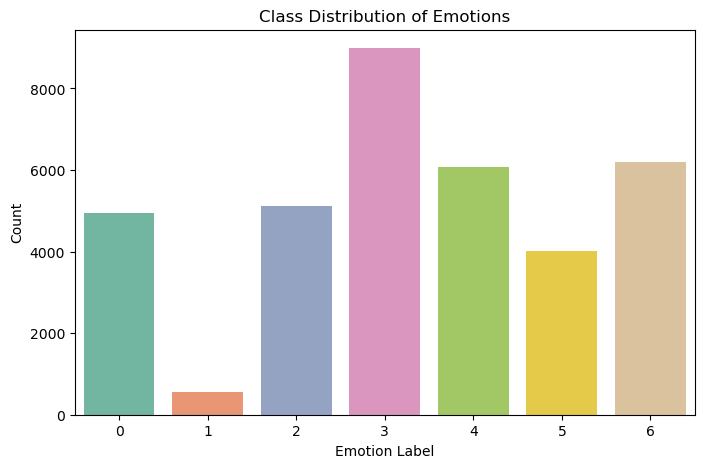

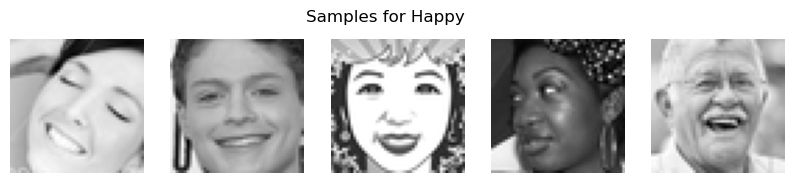


--- Image Intensity Statistics ---
       mean_intensity  std_intensity
count    35887.000000   35887.000000
mean       129.385857      54.056967
std         33.522131      13.662974
min          0.000000       0.000000
25%        106.781684      44.506909
50%        129.544271      53.635133
75%        152.629340      63.148332
max        248.087240     114.151993


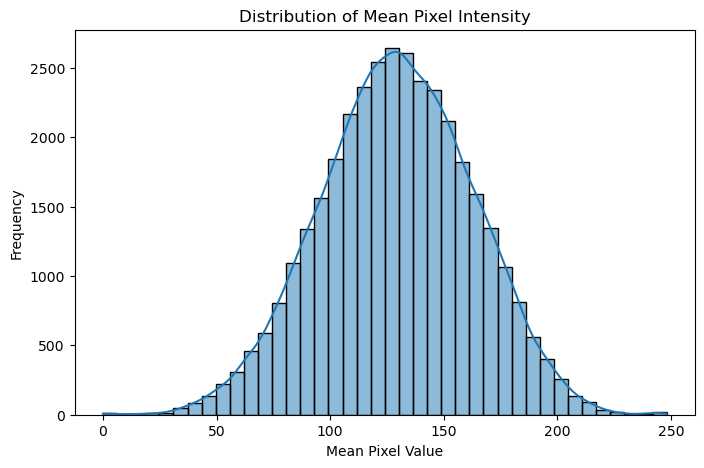


Image Shape: (48, 48)


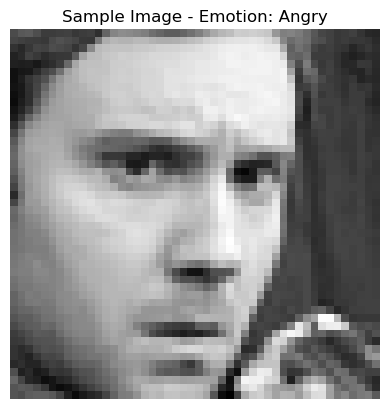

In [1]:
# ================================
# EDA for FER-2013 Facial Expression Dataset
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load FER-2013 dataset (CSV format)
# Update the path if needed
data = pd.read_csv("data/fer2013.csv")

# Quick look
print("Dataset Shape:", data.shape)
print(data.head())

# Dataset info
print("\n--- Dataset Info ---")
print(data.info())

# Class distribution
print("\n--- Class Distribution ---")
print(data['emotion'].value_counts())

# Plot class distribution
plt.figure(figsize=(8,5))
sns.countplot(x="emotion", data=data, palette="Set2")
plt.title("Class Distribution of Emotions")
plt.xlabel("Emotion Label")
plt.ylabel("Count")
plt.show()

# Map labels to emotion names (FER-2013 standard)
emotion_map = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}
data['emotion_name'] = data['emotion'].map(emotion_map)

# Check some random samples
def plot_random_images(df, emotion_id, samples=5):
    """Show random images for a given emotion label"""
    pixels_list = df[df['emotion'] == emotion_id]['pixels'].sample(samples).values
    
    plt.figure(figsize=(10,2))
    for i, px in enumerate(pixels_list, 1):
        img = np.array([int(p) for p in px.split()]).reshape(48,48)
        plt.subplot(1, samples, i)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Samples for {emotion_map[emotion_id]}")
    plt.show()

# Example: Show random samples for "Happy" (label 3)
plot_random_images(data, 3, samples=5)

# Image intensity stats
def image_stats(pixels_str):
    arr = np.array([int(p) for p in pixels_str.split()])
    return arr.mean(), arr.std()

data[['mean_intensity','std_intensity']] = data['pixels'].apply(lambda x: pd.Series(image_stats(x)))

print("\n--- Image Intensity Statistics ---")
print(data[['mean_intensity','std_intensity']].describe())

# Visualize mean intensity distribution
plt.figure(figsize=(8,5))
sns.histplot(data['mean_intensity'], bins=40, kde=True)
plt.title("Distribution of Mean Pixel Intensity")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Frequency")
plt.show()

# Image dimension check
sample_img = np.array([int(p) for p in data['pixels'].iloc[0].split()]).reshape(48,48)
print("\nImage Shape:", sample_img.shape)
plt.imshow(sample_img, cmap="gray")
plt.title(f"Sample Image - Emotion: {emotion_map[data['emotion'].iloc[0]]}")
plt.axis("off")
plt.show()


Average Face Visualization per Emotion

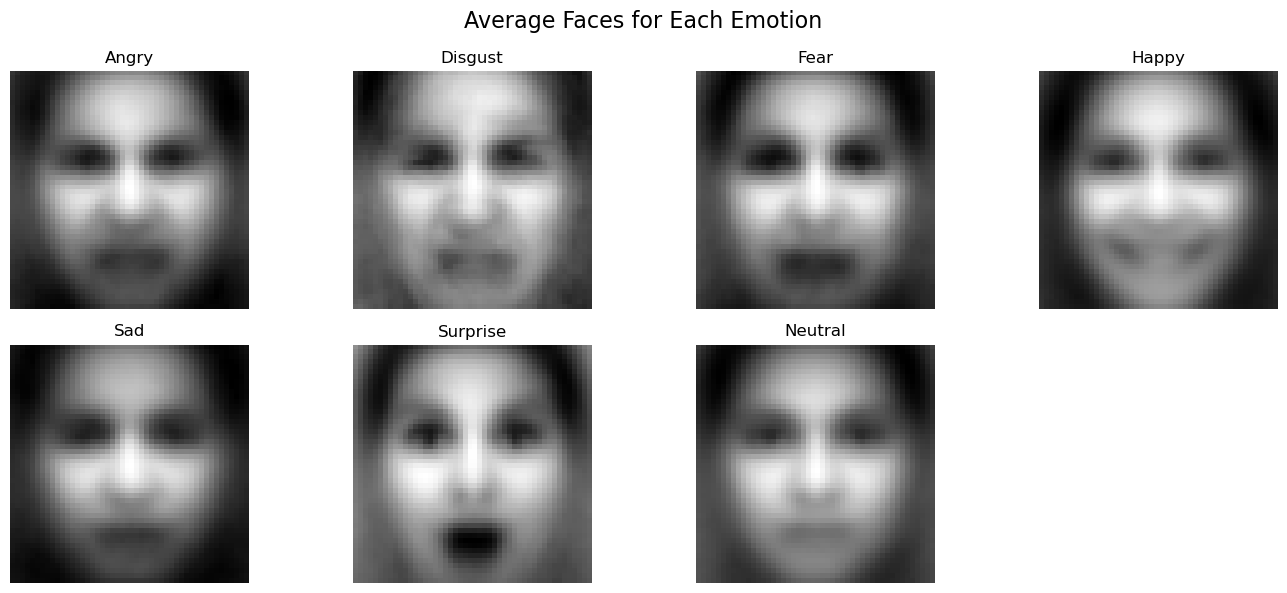

In [2]:
# ======================================
# Average Face Visualization per Emotion
# ======================================

# Compute average face for each emotion class
avg_faces = {}

for emotion_id, emotion_name in emotion_map.items():
    subset = data[data['emotion'] == emotion_id]['pixels']
    
    # Convert all pixel strings into numpy arrays
    imgs = np.array([np.fromstring(px, sep=' ') for px in subset])
    
    # Compute mean image
    avg_face = np.mean(imgs, axis=0).reshape(48,48)
    avg_faces[emotion_name] = avg_face

# Plot average faces
plt.figure(figsize=(14, 6))
for i, (emotion_name, avg_face) in enumerate(avg_faces.items(), 1):
    plt.subplot(2, 4, i)
    plt.imshow(avg_face, cmap="gray")
    plt.title(emotion_name)
    plt.axis("off")

plt.suptitle("Average Faces for Each Emotion", fontsize=16)
plt.tight_layout()
plt.show()
